## Sketch Generation

## Overview

This notebook converts the selected real furniture images into sketch-like edge images.

The prototype metadata created in `01_data_exploration.ipynb` is used to load the balanced subset of 2,500 images. Each image is resized to a fixed resolution and converted into an edge-based sketch representation.

For the first prototype, Canny edge detection is used as the main sketch generation method. A small comparison with Sobel and Laplacian edge detection is included for visual inspection, but the full prototype sketch dataset is generated using Canny.

### Setup and Imports

In [22]:
from pathlib import Path
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

sys.path.append("..")

# Reload edited src modules without restarting the kernel
%load_ext autoreload
%autoreload 2

from src import utils
from src import sketch_generation

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully


### Sketch Generation Utilities

The sketch generation logic is implemented in `src/sketch_generation.py` so that the notebook stays readable and the same functions can be reused later.

The module contains small image-processing functions:

- `to_grayscale()` converts an RGB image to grayscale, because edge detection works on intensity changes rather than color channels.
- `generate_canny_sketch()` creates the main sketch-like representation for this project using Canny edge detection.
- `generate_sobel_sketch()` creates an alternative edge representation based on Sobel gradient magnitude.
- `generate_laplacian_sketch()` creates another alternative edge representation based on second-order intensity changes.
- `save_sketch()` saves the generated edge image to disk.

Here, only Canny sketches are generated for the full prototype dataset. Sobel and Laplacian are used only for visual comparison at this stage.

**Why edge detection?**

The goal is to simulate a sketch-like version of each furniture image. Edge detection removes most color and texture information and keeps mainly object contours, inner boundaries, and strong shape structures.

This is useful for the current project because the next notebook will extract HOG features from these edge images. HOG is based on gradient orientation patterns, so it is naturally compatible with contour-based sketch representations.

### Load Prototype Metadata

The balanced prototype metadata created in Notebook 01 is loaded here. It contains 2,500 selected images: 500 per furniture category, with predefined train, validation, and test splits preserved.

In [9]:
metadata_path = utils.SPLITS_DIR / "prototype_500_per_class.csv"

df_proto = pd.read_csv(metadata_path)
df_proto["path"] = df_proto["path"].apply(Path)

print(f"Prototype metadata loaded: {len(df_proto)} images")
df_proto.head()

Prototype metadata loaded: 2500 images


,split,path,relative_path,category,class_name,style
0,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/tables/Industrial/35489industrial-dining...,tables,table,Industrial
1,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/sofas/Transitional/2428transitional-sofa...,sofas,sofa,Transitional
2,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/sofas/Transitional/1488transitional-sofa...,sofas,sofa,Transitional
3,test,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/dressers/Transitional/1623transitional-d...,dressers,dresser,Transitional
4,train,C:\Users\Vanya\PycharmProjects\PythonProject\S...,houzz/tables/Modern/9640modern-side-tables-and...,tables,table,Modern


### Sketch Generation Method

The main purpose of this notebook is to convert real furniture images into sketch-like edge representations.

Each image is loaded through `utils.load_image()`, which resizes the image to **128×128 pixels**. Resizing before sketch generation ensures that all generated sketches have the same resolution, which is required for later HOG feature extraction and classical machine learning models.

The original dataset images are square, mostly 350×350 or 224×224 pixels, so resizing to 128×128 does not introduce aspect-ratio distortion.

### Canny Edge Detection

Canny edge detection is used as the main sketch-generation method in this project.

Canny is suitable here because it produces thin, clean object contours and removes most color and texture information. This helps transform real furniture images into simplified shape-based representations.

The resulting edge images preserve important visual structures such as:

- outer furniture silhouettes;
- legs, arms, backs, shelves, and drawers;
- strong internal boundaries;
- object geometry useful for HOG features.

Sobel and Laplacian edge detection are also tested visually, but Canny is used for generating the full prototype sketch dataset.

#### Single-Image Canny Test

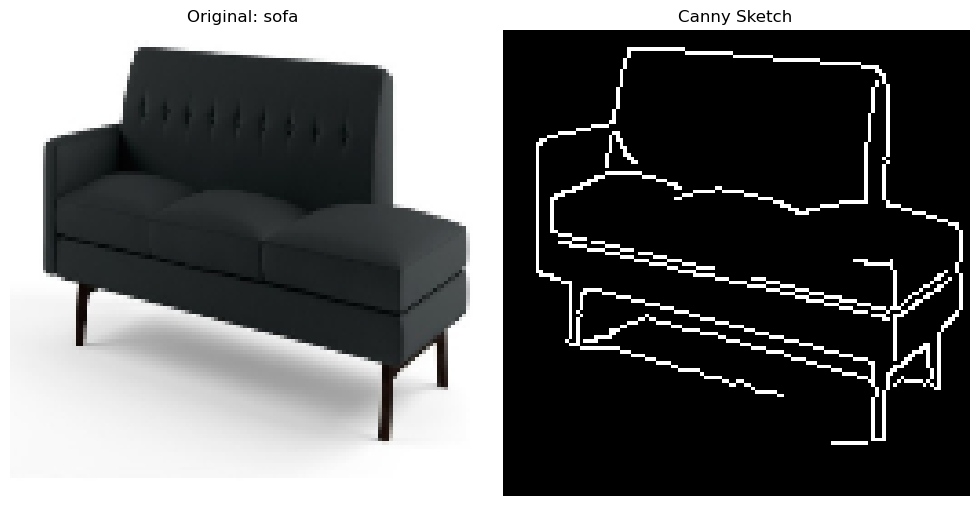

In [10]:
sample_row = df_proto.sample(1, random_state=utils.RANDOM_STATE).iloc[0]

image = utils.load_image(sample_row["path"])
canny = sketch_generation.generate_canny_sketch(image)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image)
axes[0].set_title(f"Original: {sample_row['class_name']}")
axes[0].axis("off")

axes[1].imshow(canny, cmap="gray")
axes[1].set_title("Canny Sketch")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### Observation

The single-image test confirms that the sketch-generation function works correctly. The original image is loaded through `utils.load_image()`, which resizes it to 128×128 pixels before edge detection. The Canny result preserves the main furniture contours while removing color and texture information.

This output format is suitable for the next stage, where HOG features will be extracted from the generated sketch images.

#### Light-Image Canny Test

The first Canny test uses a dark sofa, where contrast against the background is strong. Light-colored furniture on a white background is more challenging because the object boundary can be less distinct.

This additional test checks whether the same Canny thresholds still preserve useful contours for a light-colored object.

In [11]:
light_candidates = df_proto[
    df_proto["category"].isin(["beds", "dressers"])
].copy()


light_samples = light_candidates.sample(10, random_state=utils.RANDOM_STATE)

light_samples[["relative_path", "category", "class_name", "style"]]

,relative_path,category,class_name,style
1328,houzz/beds/Traditional/6015traditional-canopy-...,beds,bed,Traditional
1812,houzz/dressers/Traditional/3496traditional-dre...,dressers,dresser,Traditional
1819,houzz/beds/Contemporary/125contemporary-panel-...,beds,bed,Contemporary
1669,houzz/beds/Modern/3154modern-panel-beds.jpg,beds,bed,Modern
1051,houzz/dressers/Transitional/1705transitional-d...,dressers,dresser,Transitional
1702,houzz/beds/Contemporary/2273contemporary-kids-...,beds,bed,Contemporary
1570,houzz/dressers/Asian/20176asian-accent-chests-...,dressers,dresser,Asian
1314,houzz/beds/Beach/4959beach-style-panel-beds.jpg,beds,bed,Beach
2126,houzz/dressers/Traditional/16358traditional-si...,dressers,dresser,Traditional
354,houzz/dressers/Traditional/3513traditional-dre...,dressers,dresser,Traditional


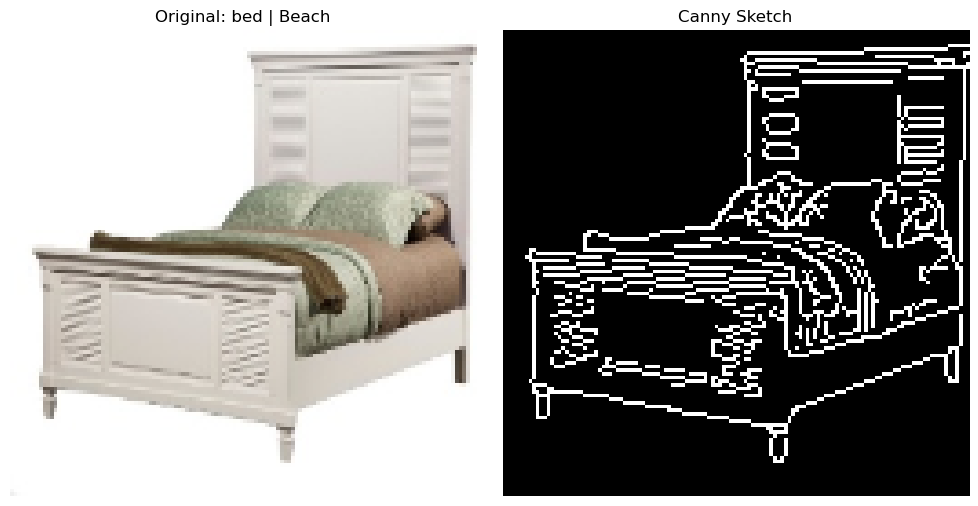

In [20]:
# Select a visually light bed example from the sampled candidates
light_row = light_samples.iloc[7]

image_light = utils.load_image(light_row["path"])
canny_light = sketch_generation.generate_canny_sketch(image_light)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_light)
axes[0].set_title(f"Original: {light_row['class_name']} | {light_row['style']}")
axes[0].axis("off")

axes[1].imshow(canny_light, cmap="gray")
axes[1].set_title("Canny Sketch")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### Observation

The light-image test shows that the selected Canny thresholds also work on a lower-contrast example. Even though the bed is light-colored and placed on a light background, the main object contour and several internal structural details are still preserved.

This suggests that the current Canny settings are usable for the first prototype. Some fine details may still vary across furniture styles, lighting, and image contrast conditions.

### Edge Method Comparison

Before generating sketches for all prototype images, three edge-detection methods are compared visually: Canny, Sobel, and Laplacian.

The comparison uses one sample image per furniture category. The purpose is to inspect which method produces the cleanest sketch-like representation while preserving useful furniture contours.

Canny is expected to produce thinner and cleaner edges, while Sobel and Laplacian may preserve more gradient texture or noise.

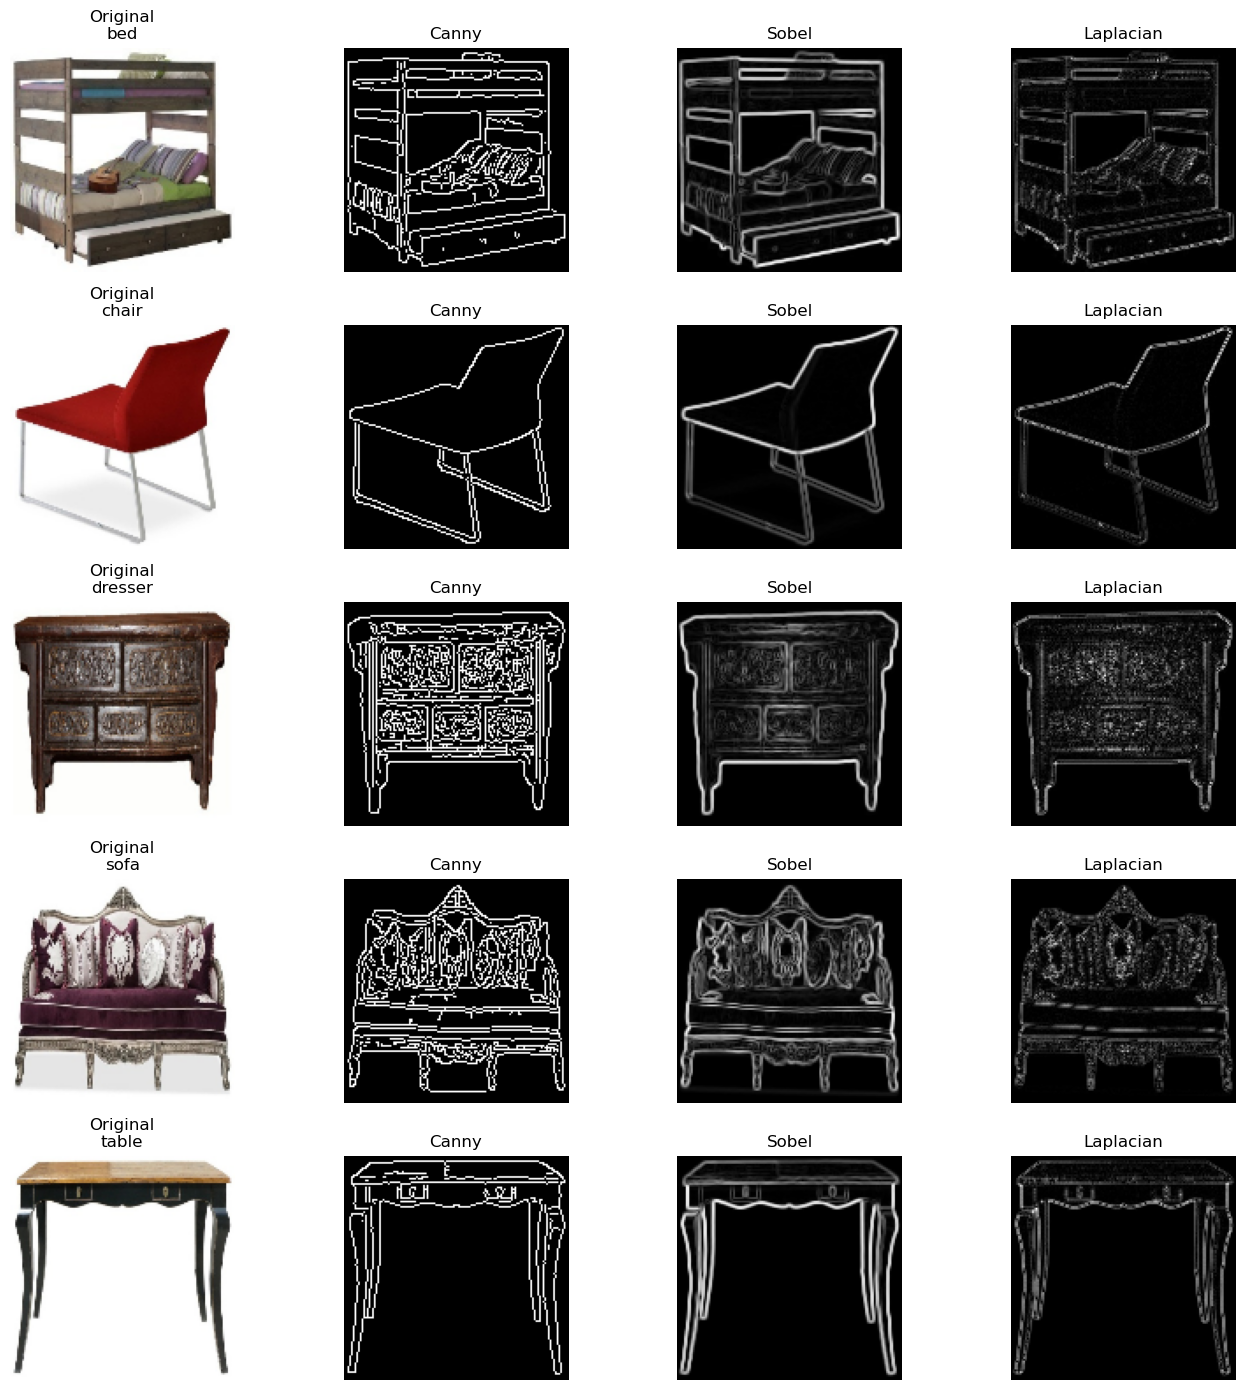

Figure saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\figures\edge_method_comparison.png


In [21]:
sample_rows = df_proto.groupby("class_name").sample(
    1, random_state=utils.RANDOM_STATE
)

fig, axes = plt.subplots(len(sample_rows), 4, figsize=(14, 14))

for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    image = utils.load_image(row["path"])

    canny = sketch_generation.generate_canny_sketch(image)
    sobel = sketch_generation.generate_sobel_sketch(image)
    laplacian = sketch_generation.generate_laplacian_sketch(image)

    images = [image, canny, sobel, laplacian]
    titles = [
        f"Original\n{row['class_name']}",
        "Canny",
        "Sobel",
        "Laplacian"
    ]

    for col_idx, (img, title) in enumerate(zip(images, titles)):
        ax = axes[row_idx, col_idx]

        if col_idx == 0:
            ax.imshow(img)
        else:
            ax.imshow(img, cmap="gray")

        ax.set_title(title)
        ax.axis("off")

plt.tight_layout()

fig_path = utils.FIGURES_DIR / "edge_method_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {fig_path}")

#### Observasion

The edge method comparison shows that all three methods capture furniture boundaries, but they produce different types of edge representations.

Canny produces the cleanest sketch-like output. It keeps the main object contours and important internal structures while reducing much of the texture and shading information.

Sobel preserves strong gradients but produces softer and thicker edge responses. Laplacian captures many fine intensity changes, but this can introduce texture-like noise, especially for decorative furniture surfaces.

For this reason, Canny is selected as the main sketch generation method for the prototype dataset.

### Generate Canny Sketch Dataset

After testing the sketch-generation method on individual examples, Canny sketches are generated for the full prototype subset.

The generated sketches are saved inside `data/sketches/canny/`. To keep the dataset organized, the saved files preserve both the original split information and the furniture class label. This means that each sketch can still be traced back to its train, validation, or test split and to its furniture category.

Each generated sketch is saved with the same filename as the original image. The metadata table is also updated with a new column containing the generated sketch path.

In [23]:
CANNY_OUTPUT_DIR = utils.SKETCHES_DIR / "canny"

sketch_paths = []

for _, row in tqdm(df_proto.iterrows(), total=len(df_proto)):
    image = utils.load_image(row["path"])

    if image is None:
        sketch_paths.append(None)
        continue

    canny_sketch = sketch_generation.generate_canny_sketch(image)

    output_dir = CANNY_OUTPUT_DIR / row["split"] / row["class_name"]
    output_filename = Path(row["relative_path"]).name
    output_path = output_dir / output_filename

    sketch_generation.save_sketch(canny_sketch, output_path)

    sketch_paths.append(output_path)

df_proto["canny_sketch_path"] = sketch_paths

print("Canny sketch generation completed.")
print(f"Sketches generated: {df_proto['canny_sketch_path'].notna().sum()}")
print(f"Missing sketches: {df_proto['canny_sketch_path'].isna().sum()}")

100%|██████████| 2500/2500 [00:08<00:00, 297.63it/s]

Canny sketch generation completed.
Sketches generated: 2500
Missing sketches: 0


#### Observation

Canny sketches were successfully generated for all 2,500 prototype images. No images failed during loading or sketch generation.

The generated sketches are saved locally under `data/sketches/canny/`, organized by split and class. The updated metadata now includes a `canny_sketch_path` column, which will be used in the next notebook for feature extraction.

In [24]:
metadata_with_sketches_path = utils.SPLITS_DIR / "prototype_500_per_class_with_sketches.csv"

df_proto.to_csv(metadata_with_sketches_path, index=False)

print(f"Updated metadata saved to: {metadata_with_sketches_path}")
print(f"File size: {metadata_with_sketches_path.stat().st_size / 1024:.1f} KB")

Updated metadata saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\data\splits\prototype_500_per_class_with_sketches.csv
File size: 1090.6 KB


### Visual Quality Check

After generating the full sketch dataset, a final visual check is performed on a small sample of saved Canny sketches.

The purpose of this section is to confirm that the saved sketches preserve the main furniture contours and that the output files were written correctly to disk. To make the comparison easier, each saved sketch is displayed next to its original image.

Two examples per furniture category are sampled from the generated dataset.

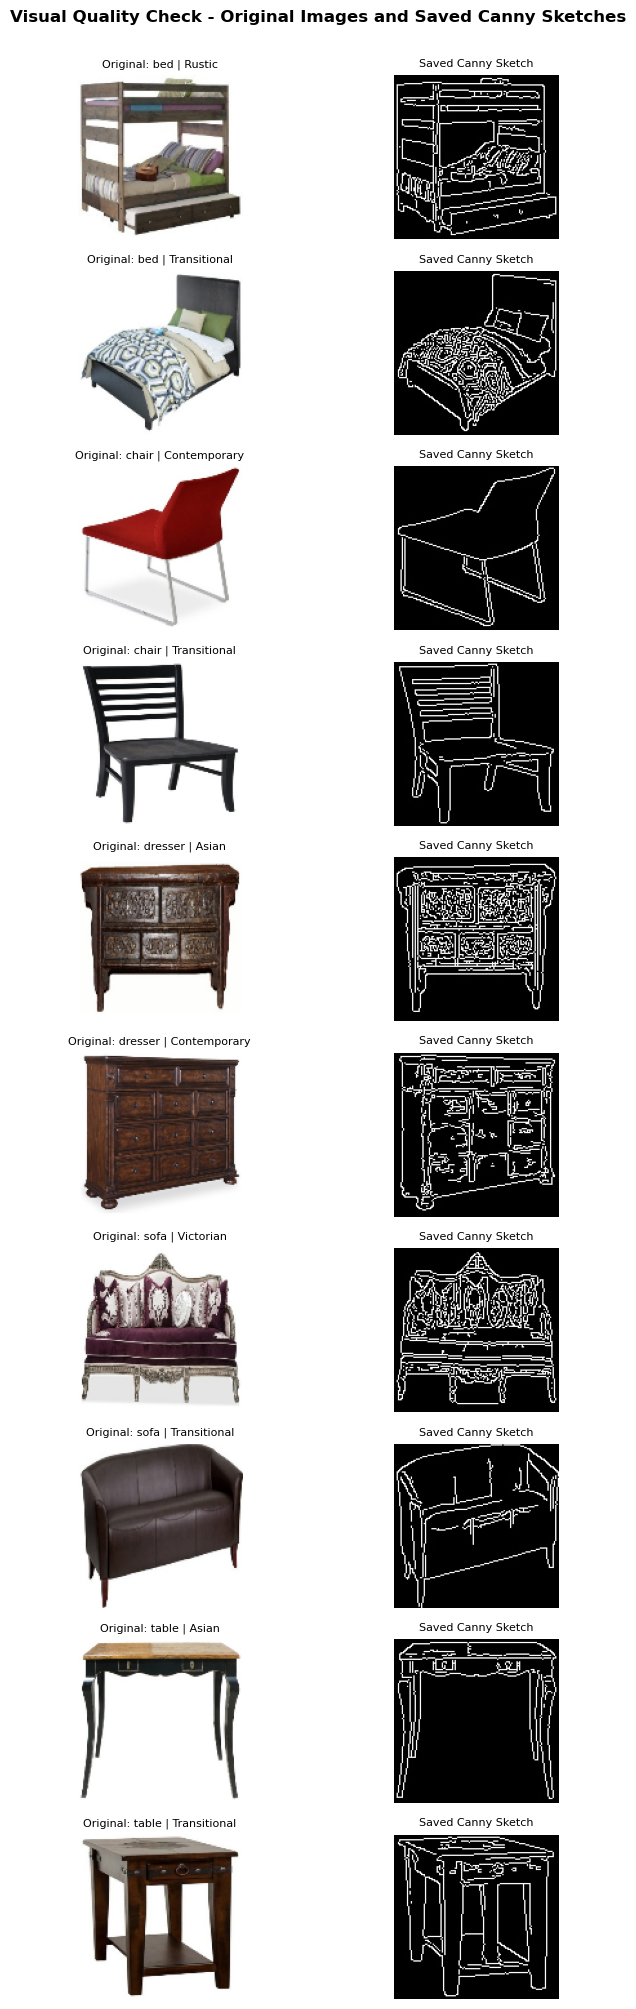

Figure saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\figures\visual_quality_check.png


In [25]:
sample_per_class = df_proto.groupby("class_name").sample(
    2, random_state=utils.RANDOM_STATE
).reset_index(drop=True)

fig, axes = plt.subplots(len(sample_per_class), 2, figsize=(8, 20))

for row_idx, row in sample_per_class.iterrows():
    original = utils.load_image(row["path"])
    sketch = cv2.imread(str(row["canny_sketch_path"]), cv2.IMREAD_GRAYSCALE)

    # Original image
    axes[row_idx, 0].imshow(original)
    axes[row_idx, 0].set_title(
        f"Original: {row['class_name']} | {row['style']}",
        fontsize=8
    )
    axes[row_idx, 0].axis("off")

    # Saved sketch
    axes[row_idx, 1].imshow(sketch, cmap="gray")
    axes[row_idx, 1].set_title("Saved Canny Sketch", fontsize=8)
    axes[row_idx, 1].axis("off")

plt.suptitle(
    "Visual Quality Check - Original Images and Saved Canny Sketches",
    fontsize=12,
    fontweight="bold",
    y=1.002
)
plt.tight_layout()

fig_path = utils.FIGURES_DIR / "visual_quality_check.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {fig_path}")

The visual quality check confirms that the saved Canny sketches preserve the main furniture structure across all five categories. Outer silhouettes, legs, backs, drawers, shelves, and other strong shape boundaries remain visible in most examples.

As expected, furniture with richer texture or decorative details produces denser edge patterns, while simpler objects produce cleaner contour maps. This variation is acceptable for the first prototype and will later be reflected in the HOG feature representation.

Overall, the generated sketch dataset is suitable for the next step of the pipeline: HOG feature extraction.

### Summary and Next Steps

This notebook generated sketch-like edge images for the balanced prototype dataset.

Main outcomes:

- The prototype metadata from Notebook 01 was loaded successfully.
- The sketch-generation functions were implemented in `src/sketch_generation.py`.
- Canny, Sobel, and Laplacian edge detection were compared visually.
- Canny was selected as the main sketch-generation method because it produced cleaner and thinner contour-based sketches.
- Canny sketches were generated for all **2,500 prototype images**.
- No images failed during sketch generation.
- The updated metadata now links each original image to its generated Canny sketch.
- Visual inspection confirms that the generated sketches preserve the main furniture contours.

The next notebook, `03_feature_extraction.ipynb`, will extract HOG features from the generated sketch images and prepare the data for classical machine learning models.